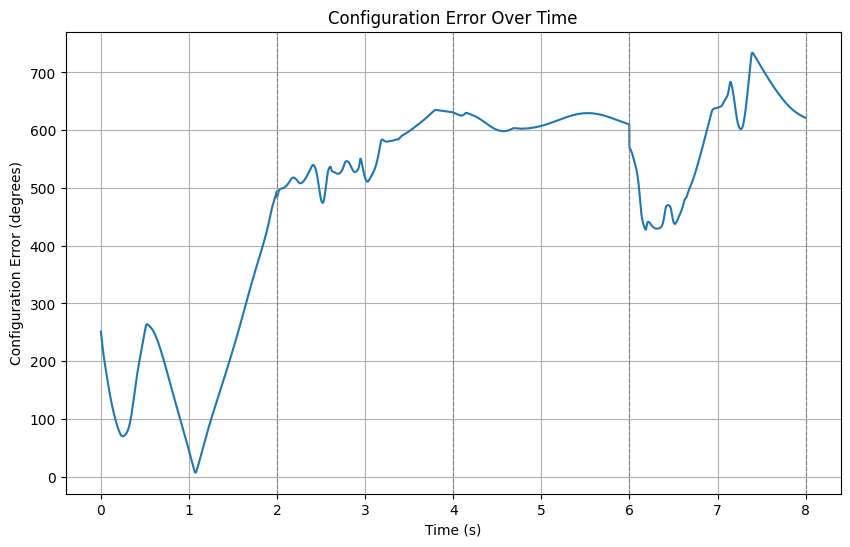

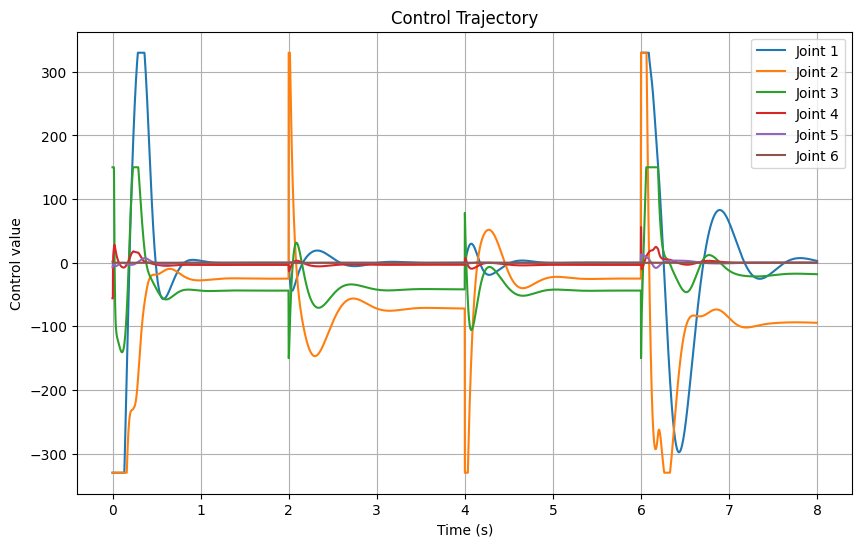

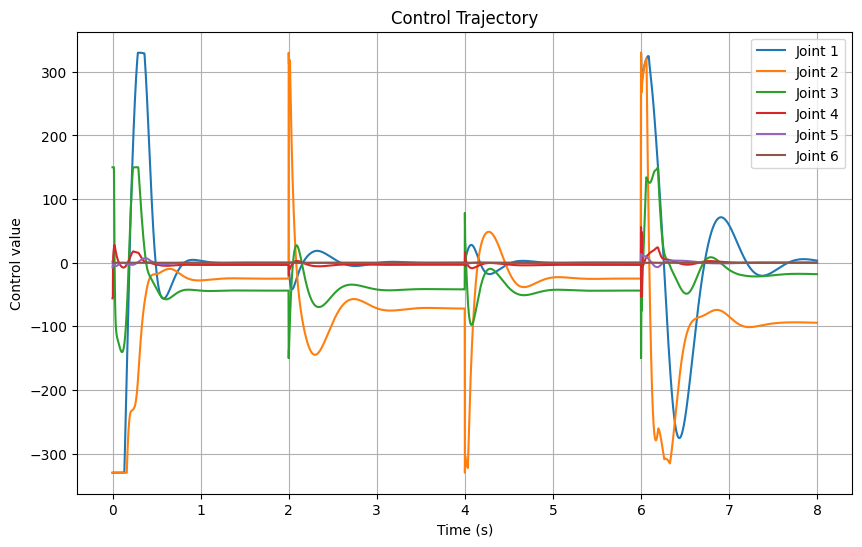

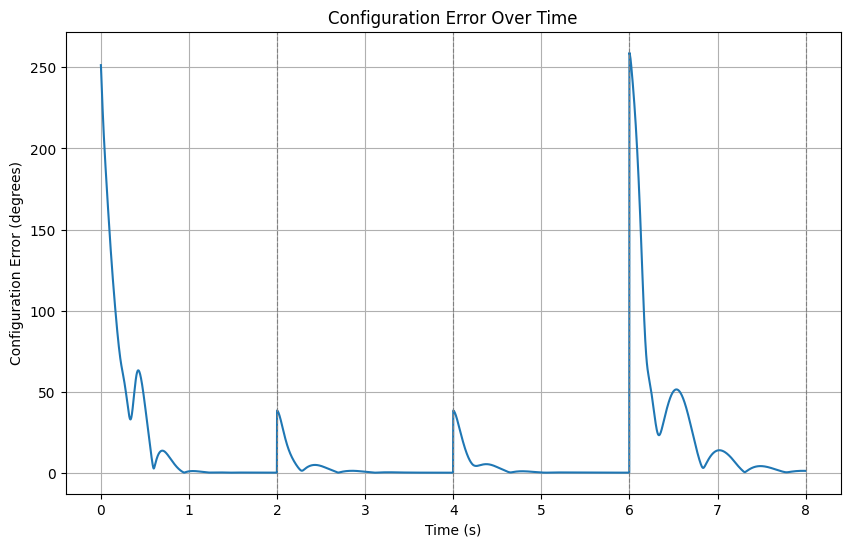

In [6]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox
import pinocchio as pin
import numpy as np
import mujoco

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

controller = RobotController(robot_pin_model)
xs, us = [], []
for i in range(len(path) - 1):
    t_xs, t_us = controller.compute_control(q_start=path[i], 
                                            q_target=path[i+1], 
                                            T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                            option="pd")
    xs.extend(t_xs)
    us.extend(t_us)

# robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
# robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us, dt=DT)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)


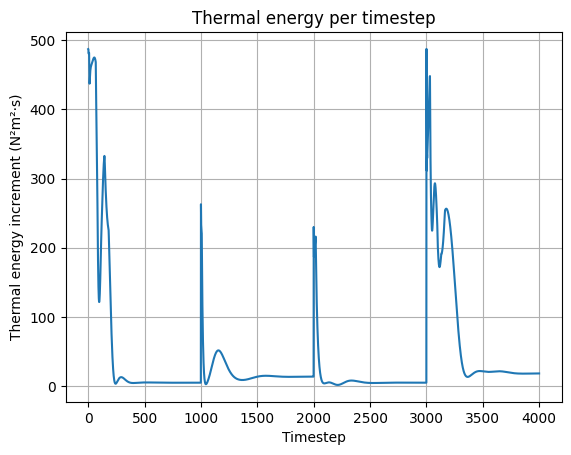

Thermal energy: 183590.80851076526


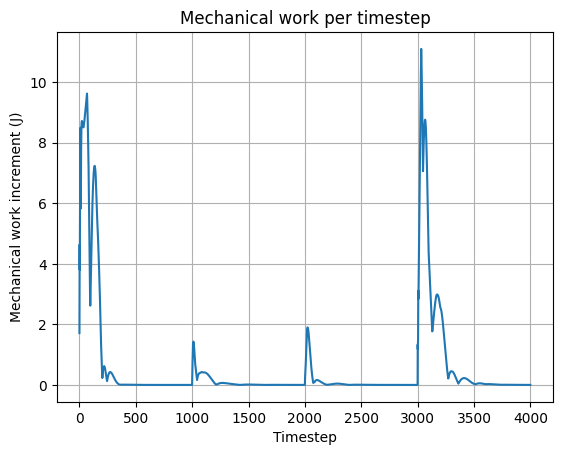

Mechanical work: 2628.9547757985747


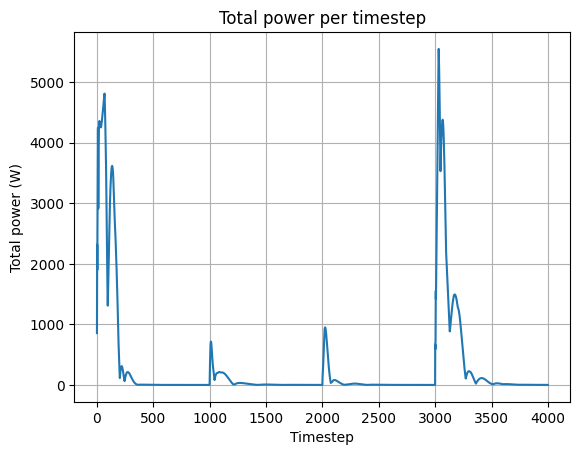

Peak power: 5550.150002533563


In [7]:
from optimal.metrics import thermal_energy, mechanical_work, peak_power

E_th  = thermal_energy(us_real, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_real, xs_real, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_real, xs_real, True)
print("Peak power:", P_peak)

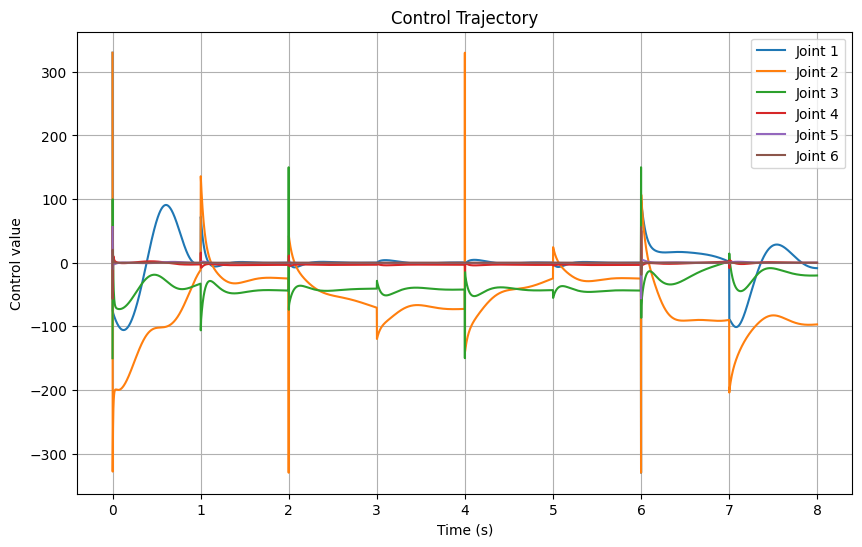

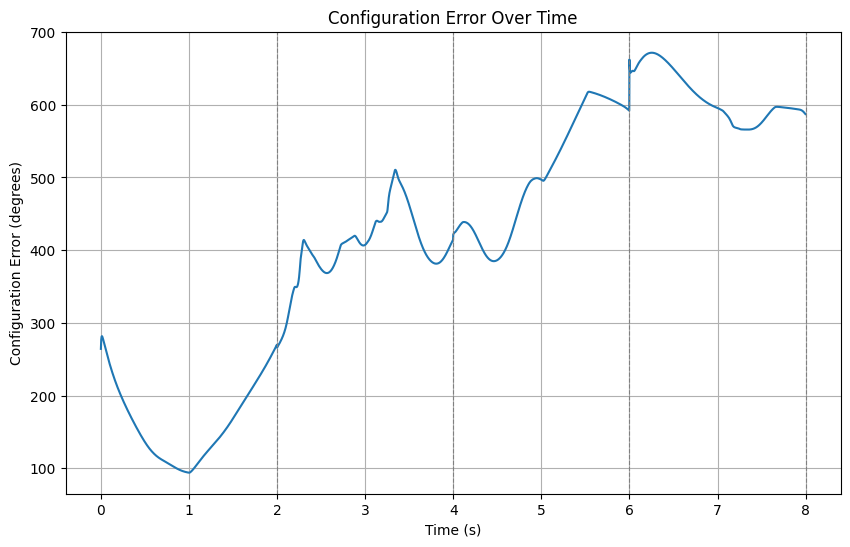

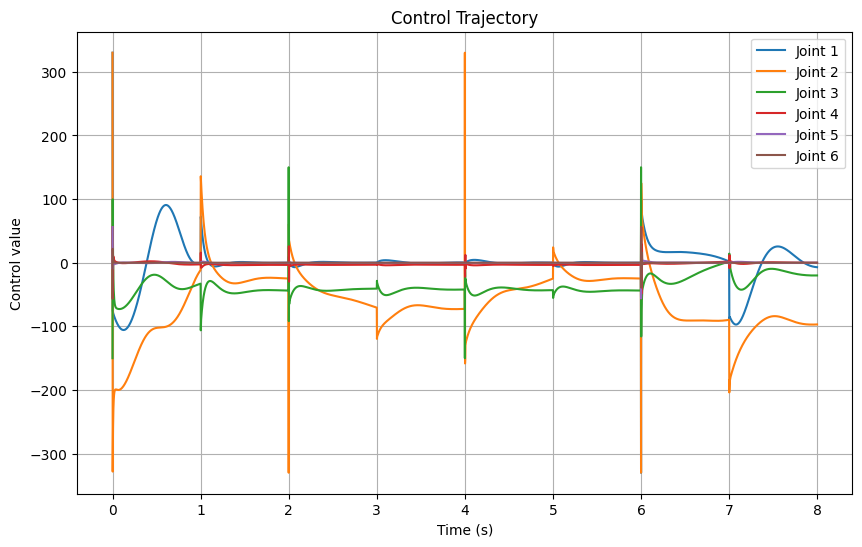

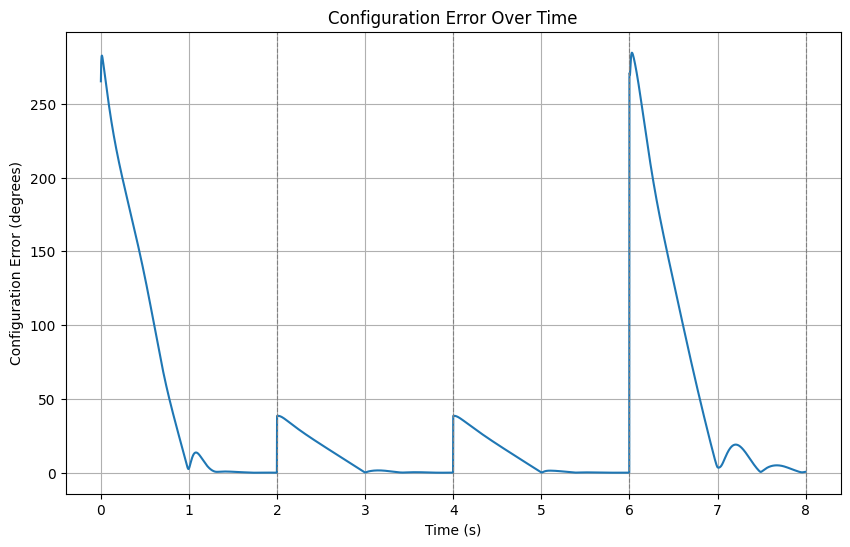

In [8]:
xs, us = [], []
for i in range(len(path) - 1):
    t_xs, t_us = controller.compute_control(q_start=path[i], 
                                            q_target=path[i+1], 
                                            T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                            alpha=0.5,
                                            option="pd")
    xs.extend(t_xs)
    us.extend(t_us)
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize(mode="control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)


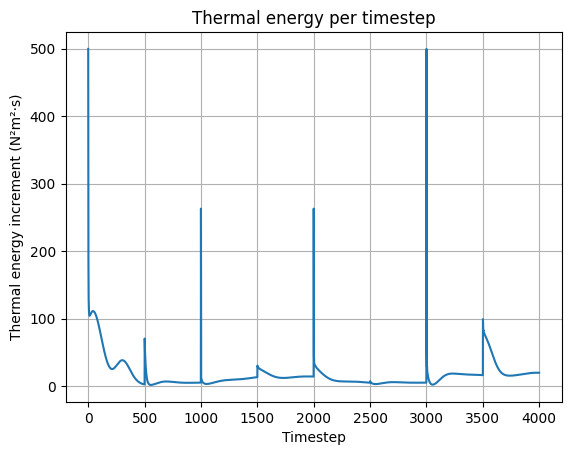

Thermal energy: 68028.62211838241


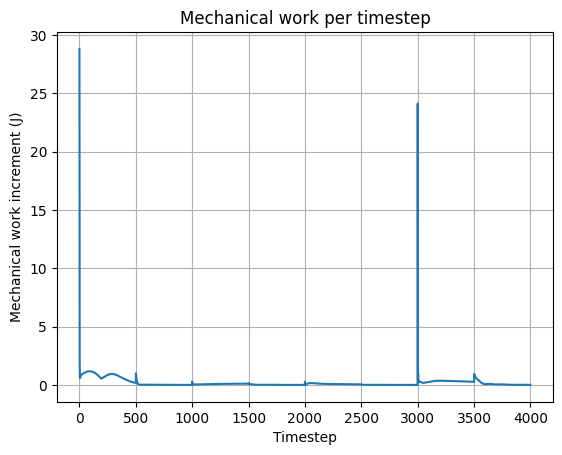

Mechanical work: 751.3959971277038


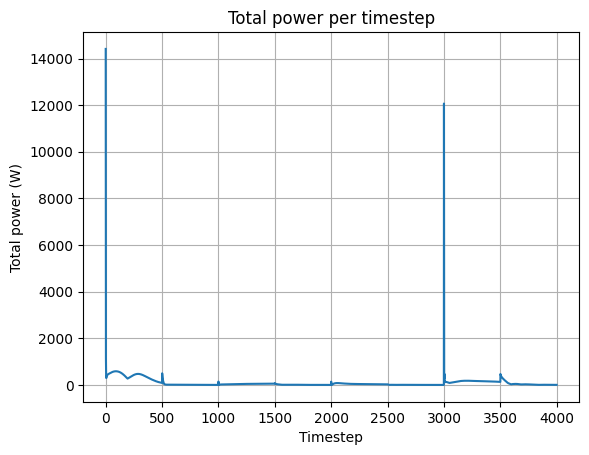

Peak power: 14411.522990179341


In [9]:
E_th  = thermal_energy(us_real, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_real, xs_real, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_real, xs_real, True)
print("Peak power:", P_peak)